# Factor Investing in Indian Equity Markets (2021–2024)

**Role alignment:** Financial Data Analyst | Investment Data Scientist | Quant Research Intern  

This notebook provides an analytical walkthrough of a factor investing study conducted on Indian equities in the post-COVID period. The objective is to evaluate the performance of Value, Momentum, and Low-Volatility factors, assess their risk characteristics, and understand their behavior across macroeconomic regimes.

The underlying factor construction, backtesting, and optimization logic is implemented using modular Python scripts. This notebook focuses on:
- Exploratory analysis
- Visualization
- Investment interpretation


## 1. Data Overview

- **Universe:** ~NSE-listed equities selected based on market capitalization (Jan 2021)
- **Frequency:** Monthly
- **Period:** January 2021 – December 2024
- **Factors:**
  - Value (Book-to-Market)
  - Momentum (12–1 strategy)
  - Low Volatility (6-month rolling volatility)

All factor returns are constructed as **long–short portfolios** and evaluated net of transaction costs.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load factor returns
factors = pd.read_csv(
    "../data/processed/factor_returns.csv",
    index_col=0,
    parse_dates=True
)

factors.head()


,Value,Momentum,LowVol
Date,,,
2022-01-31,0.119351,0.004745,-0.061187
2022-02-28,-0.015342,-0.013816,0.008697
2022-03-31,-0.001564,-0.022809,-0.065448
2022-04-30,0.041330,-0.035305,-0.005581
2022-05-31,-0.037856,-0.016217,0.017406


## 2. Data Quality & Summary Statistics

Before evaluating performance, we examine basic descriptive statistics of factor returns to understand their distribution, volatility, and central tendencies.


In [2]:
factors.describe().T


,count,mean,std,min,25%,50%,75%,max
Value,36.0,0.010005,0.054258,-0.140757,-0.027842,0.005895,0.045815,0.119351
Momentum,36.0,0.002117,0.039049,-0.081165,-0.022546,-0.007178,0.032549,0.089207
LowVol,36.0,-0.006552,0.038061,-0.085093,-0.022150,-0.005006,0.014593,0.094494


## 3. Factor Performance: Equity Curves

We visualize cumulative performance of each factor to assess:
- Return consistency
- Drawdowns
- Relative dominance across time


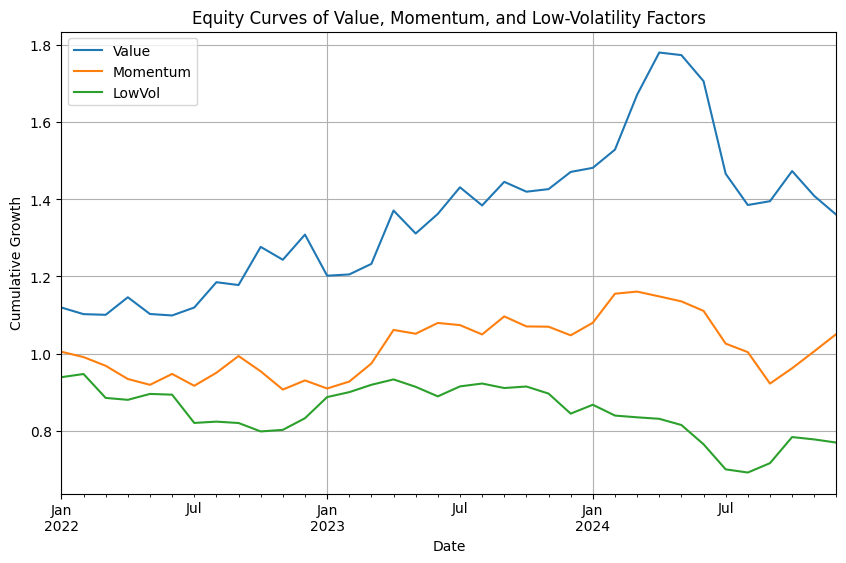

In [3]:
(1 + factors).cumprod().plot(
    figsize=(10,6),
    title="Equity Curves of Value, Momentum, and Low-Volatility Factors"
)
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.grid(True)
plt.show()


### Observations
- Momentum exhibits strong performance during liquidity-driven phases but shows higher volatility.
- Low-volatility provides smoother returns and lower drawdowns.
- Value demonstrates cyclicality, with periods of underperformance followed by recovery.

This highlights the importance of diversification across factors rather than reliance on a single strategy.


## 4. Diversified Factor Portfolio

From an investment perspective, combining factors can reduce volatility and improve risk-adjusted performance. As a baseline, we examine an equal-weighted factor portfolio.


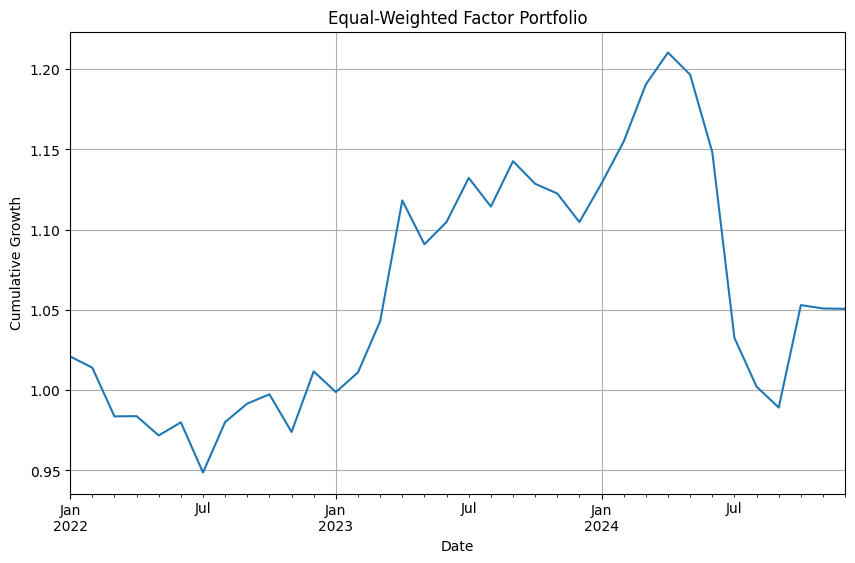

In [4]:
equal_weighted = factors.mean(axis=1)

(1 + equal_weighted).cumprod().plot(
    figsize=(10,6),
    title="Equal-Weighted Factor Portfolio"
)
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.grid(True)
plt.show()


## 5. Risk & Performance Metrics

We evaluate factors using commonly used investment metrics:
- CAGR
- Volatility
- Sharpe Ratio
- Maximum Drawdown


In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from backtest.performance import cagr, volatility, sharpe, max_drawdown

summary = {}

for col in factors.columns:
    r = factors[col].dropna()
    summary[col] = {
        "CAGR": cagr(r),
        "Volatility": volatility(r),
        "Sharpe Ratio": sharpe(r),
        "Max Drawdown": max_drawdown(r)
    }

pd.DataFrame(summary).T


ModuleNotFoundError: No module named 'backtest'

## 6. Macro-Aware Interpretation

Factor performance is not static and varies across economic regimes.

In the post-COVID Indian market:
- Momentum benefited from accommodative monetary policy and excess liquidity.
- Low-volatility strategies provided downside protection during tightening phases.
- Value showed recovery tendencies during stabilization periods.

This emphasizes the importance of macro-aware factor allocation rather than static exposure.


## 7. Conclusion

This analysis demonstrates that:
- Equity factor premiums exist in Indian markets
- Factor returns are regime-dependent
- Diversified factor portfolios improve risk-adjusted outcomes

The combination of modular research code and an analytical notebook enables both reproducibility and interpretability — a critical requirement for financial analytics and investment research roles.
